# Baseline Bayesian agent on a Watts–Strogatz network

Agents update beliefs in log-odds space:

$$\ell_i \leftarrow \ell_i + \text{gain} \cdot w_{\text{novelty}} \cdot w_{\text{compat}} \cdot w_{\text{source}} \cdot w_{\text{salience}} \cdot \text{LLR}(c)$$

**Baseline:** all weights = 1 except $w_{\text{novelty}}$ = 0 on repeated claims (normative de-duplication). No biases active.

**Per-step loop:** reception → belief update → emission
- *Reception* (`select_neighbor`): agent reads the last broadcast of a random neighbour
- *Update* (`step`): Bayesian log-odds update, claim marked as seen
- *Emission* (`emit`): agent stochastically samples one claim from its repertoire, weighted toward sign-agreement with its current belief $\ell_i$

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace

from rankers.config import Config
from rankers.simulate import run, run_replicates


In [18]:
from rankers.simulate import run
from rankers.config import Config
from rankers.viz import plot_belief_trajectories
import matplotlib.pyplot as plt

biases = {
    "Baseline (rational)":            Config(biases=("baseline",),      n_tracked=100),
    "Confirmation (strength=2.0)":    Config(biases=("confirmation",),  n_tracked=100, confirmation_strength=2.0),
    "Negativity (multiplier=2.0)":    Config(biases=("negativity",),    n_tracked=100, negativity_multiplier=2.0),
    "Conservatism (strength=1.0)":    Config(biases=("conservatism",),  n_tracked=100, conservatism_strength=1.0),
    "Illusory Truth (factor = 10)":  Config(biases=("illusory_truth",), n_tracked=100, illusory_truth_factor=10),
}

results = {label: run(cfg) for label, cfg in biases.items()}

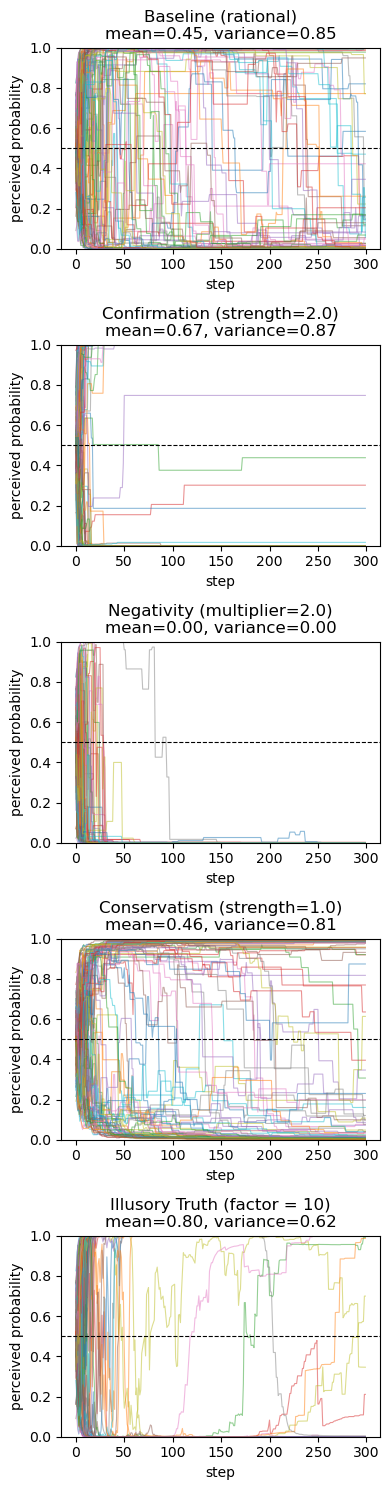

In [19]:
fig, axes = plt.subplots( len(biases),1, figsize=( 4,3 * len(biases)), sharey=True)

for ax, (label, result) in zip(axes, results.items()):
    plot_belief_trajectories(result, ax=ax)
    probabilities = 1.0 / (1.0 + np.exp(-result.final_beliefs))
    mean = probabilities.mean()
    variance = probabilities.var()*4
    ax.set_title(f"{label}\nmean={mean:.2f}, variance={variance:.2f}")

plt.tight_layout()
plt.show()

In [30]:
from rankers.simulate import run
from rankers.config import Config
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import replace

biases = {
    "Baseline (rational)":            Config(biases=("baseline",),      n_tracked=500),
    "Confirmation (strength=2.0)":    Config(biases=("confirmation",),  n_tracked=500, confirmation_strength=2.0),
    "Negativity (multiplier=2.0)":    Config(biases=("negativity",),    n_tracked=500, negativity_multiplier=2.0),
    "Conservatism (strength=1.0)":    Config(biases=("conservatism",),  n_tracked=500, conservatism_strength=1.0),
    "Illusory Truth (factor = 10)":  Config(biases=("illusory_truth",), n_tracked=500, illusory_truth_factor=10),
}

n_reps = 100


def generate_data(cfg, n_reps):
    mean_sum = 0.0       # running sum of per-step probability mean, shape (T,)
    variance_sum = 0.0   # running sum of per-step probability variance, shape (T,)
    for rep in range(n_reps):
        result = run(replace(cfg, seed=rep))
        probabilities = 1.0 / (1.0 + np.exp(-result.belief_trajectories))  # (T, n_tracked)
        mean_sum += probabilities.mean(axis=1)
        variance_sum += probabilities.var(axis=1)

    mean_over_reps = mean_sum / n_reps
    variance_over_reps = variance_sum / n_reps
    steps = np.arange(mean_over_reps.shape[0]) * cfg.record_every
    return steps, mean_over_reps, variance_over_reps





data = {label: generate_data(cfg, n_reps) for label, cfg in biases.items()}


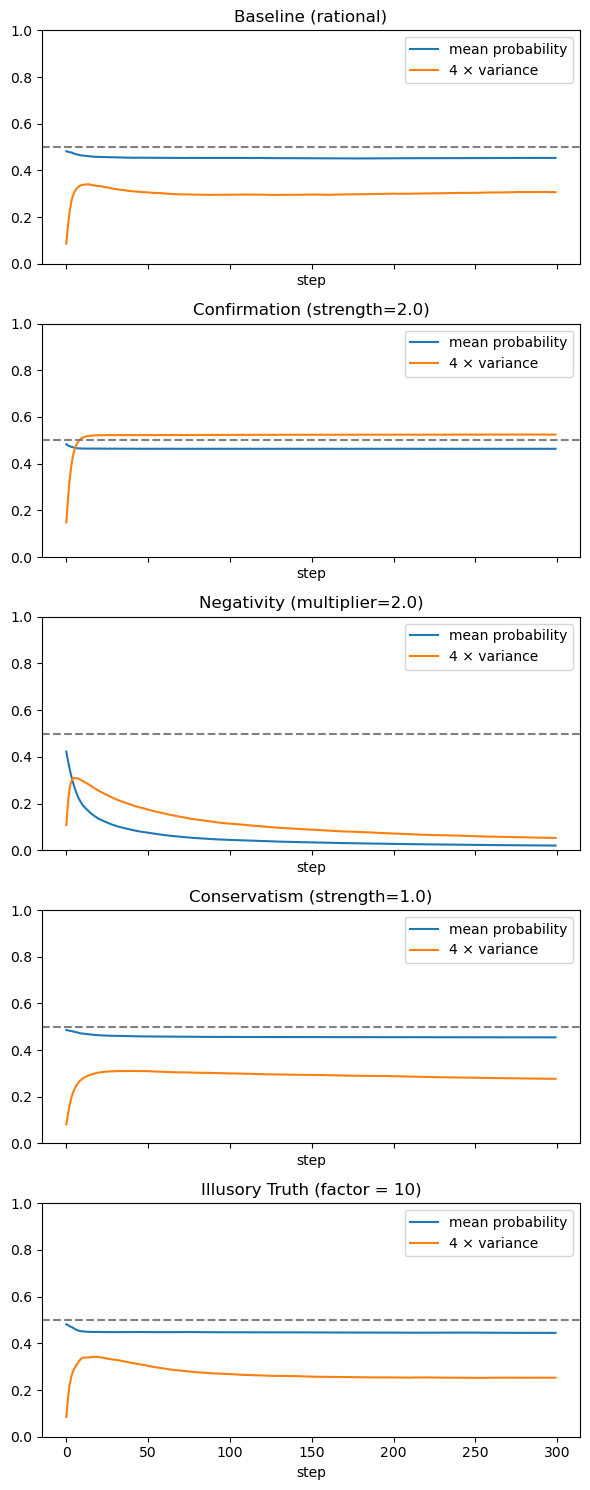

In [31]:
def plot_data(ax, label, steps, mean_over_reps, variance_over_reps):
    ax.plot(steps, mean_over_reps, label="mean probability")
    ax.plot(steps, 4 * variance_over_reps, label="4 × variance")
    ax.set_title(label)
    ax.set_xlabel("step")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.axhline(0.5, color="gray", linestyle="--", label="50% threshold")

fig, axes = plt.subplots(len(biases), 1, figsize=(6, 3 * len(biases)), sharex=True)
for ax, (label, (steps, mean_over_reps, variance_over_reps)) in zip(axes, data.items()):
    plot_data(ax, label, steps, mean_over_reps, variance_over_reps)

plt.tight_layout()
plt.show()


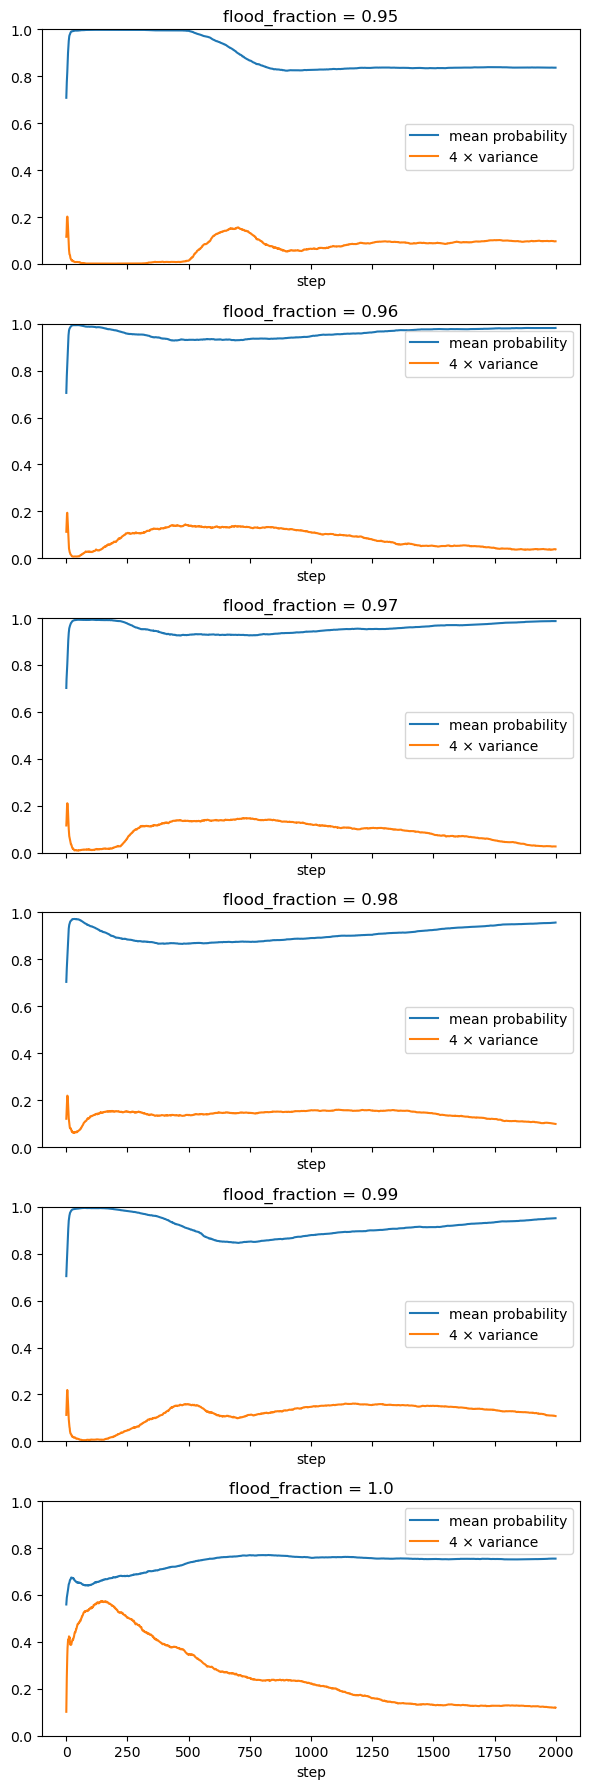

In [5]:
from rankers.simulate import run
from rankers.config import Config
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import replace

flood_fractions = [0.95, 0.96, 0.97, 0.98, 0.99, 1.0]
n_reps = 5
base_cfg = Config(n_tracked=500, n=500, mu_signal=1.0, sigma_signal=1.0, sigma_flood=1.0)


def generate_data(cfg, n_reps):
    mean_sum = 0.0       # running sum of per-step probability mean, shape (T,)
    variance_sum = 0.0   # running sum of per-step probability variance, shape (T,)
    for rep in range(n_reps):
        result = run(replace(cfg, seed=rep))
        probabilities = 1.0 / (1.0 + np.exp(-result.belief_trajectories))
        mean_sum += probabilities.mean(axis=1)
        variance_sum += probabilities.var(axis=1)
    mean_over_reps = mean_sum / n_reps
    variance_over_reps = variance_sum / n_reps
    steps = np.arange(mean_over_reps.shape[0]) * cfg.record_every
    return steps, mean_over_reps, variance_over_reps


def plot_data(ax, label, steps, mean_over_reps, variance_over_reps):
    ax.plot(steps, mean_over_reps, label="mean probability")
    ax.plot(steps, 4 * variance_over_reps, label="4 × variance")
    ax.set_title(label)
    ax.set_xlabel("step")
    ax.set_ylim(0, 1)
    ax.legend()


data = {
    f"flood_fraction = {f}": generate_data(replace(base_cfg, flood_fraction=f), n_reps)
    for f in flood_fractions
}

fig, axes = plt.subplots(len(data), 1, figsize=(6, 3 * len(data)), sharex=True)
for ax, (label, (steps, mean_over_reps, variance_over_reps)) in zip(axes, data.items()):
    plot_data(ax, label, steps, mean_over_reps, variance_over_reps)

plt.tight_layout()
plt.show()

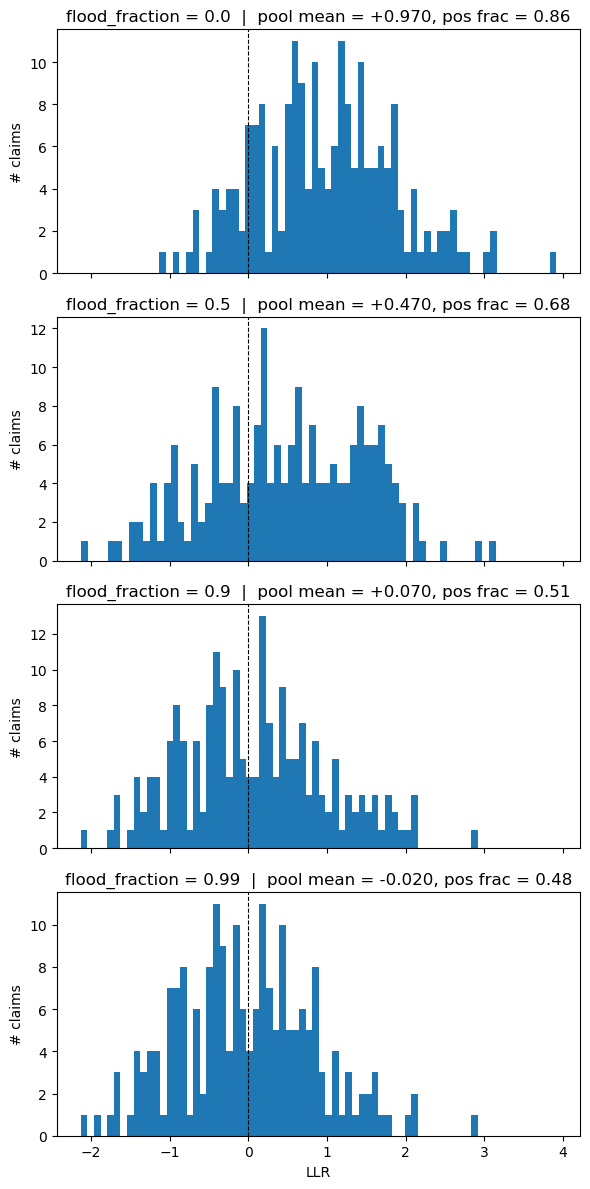

In [4]:
from rankers.config import Config
from rankers.claims import build_claims
import numpy as np
import matplotlib.pyplot as plt

flood_fractions = [0.0, 0.5, 0.9, 0.99]

fig, axes = plt.subplots(len(flood_fractions), 1, figsize=(6, 3 * len(flood_fractions)), sharex=True)

for ax, ff in zip(axes, flood_fractions):
    cfg = Config(flood_fraction=ff, mu_signal=1.0, sigma_signal=1.0, sigma_flood=1.0)
    rng = np.random.default_rng(cfg.seed)
    llr = build_claims(cfg, rng)

    ax.hist(llr, bins=60)
    ax.axvline(0.0, color="black", lw=0.8, ls="--")
    ax.set_title(f"flood_fraction = {ff}  |  pool mean = {llr.mean():+.3f}, pos frac = {(llr > 0).mean():.2f}")
    ax.set_ylabel("# claims")

axes[-1].set_xlabel("LLR")
plt.tight_layout()
plt.show()

In [9]:
from rankers.simulate import run
from rankers.config import Config
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import replace

n_reps = 10
base_cfg = Config(n_tracked=200, n=200, flood_fraction=1.0,
                  mu_signal=1.0, sigma_signal=1.0, sigma_flood=1.0)

rankers = ["baseline", "similarity", "engagement",
           "post_popularity", "user_popularity", "chronological"]

# Each entry: the config overrides that turn that bias on.
bias_settings = {
    "baseline":       {"biases": ("baseline",)},
    "confirmation":   {"biases": ("confirmation",),   "confirmation_strength": 1.0},
    "negativity":     {"biases": ("negativity",),     "negativity_multiplier": 2.0},
    "illusory_truth": {"biases": ("illusory_truth",), "illusory_truth_factor": 3.0},
    "conservatism":   {"biases": ("conservatism",),   "conservatism_strength": 1.0},
}


def generate_data(cfg, n_reps):
    mean_sum = 0.0       # running sum of per-step probability mean, shape (T,)
    variance_sum = 0.0   # running sum of per-step probability variance, shape (T,)
    for rep in range(n_reps):
        result = run(replace(cfg, seed=rep))
        probabilities = 1.0 / (1.0 + np.exp(-result.belief_trajectories))
        mean_sum += probabilities.mean(axis=1)
        variance_sum += probabilities.var(axis=1)
    mean_over_reps = mean_sum / n_reps
    variance_over_reps = variance_sum / n_reps
    steps = np.arange(mean_over_reps.shape[0]) * cfg.record_every
    return steps, mean_over_reps, variance_over_reps


def plot_data(ax, steps, mean_over_reps, variance_over_reps):
    ax.plot(steps, mean_over_reps, label="average opinion")
    ax.plot(steps, 4 * variance_over_reps, label="polarization")
    ax.set_ylim(0, 1)


data = {
    (ranker, bias_name): generate_data(
        replace(base_cfg, ranker=ranker, **overrides), n_reps
    )
    for ranker in rankers
    for bias_name, overrides in bias_settings.items()
}

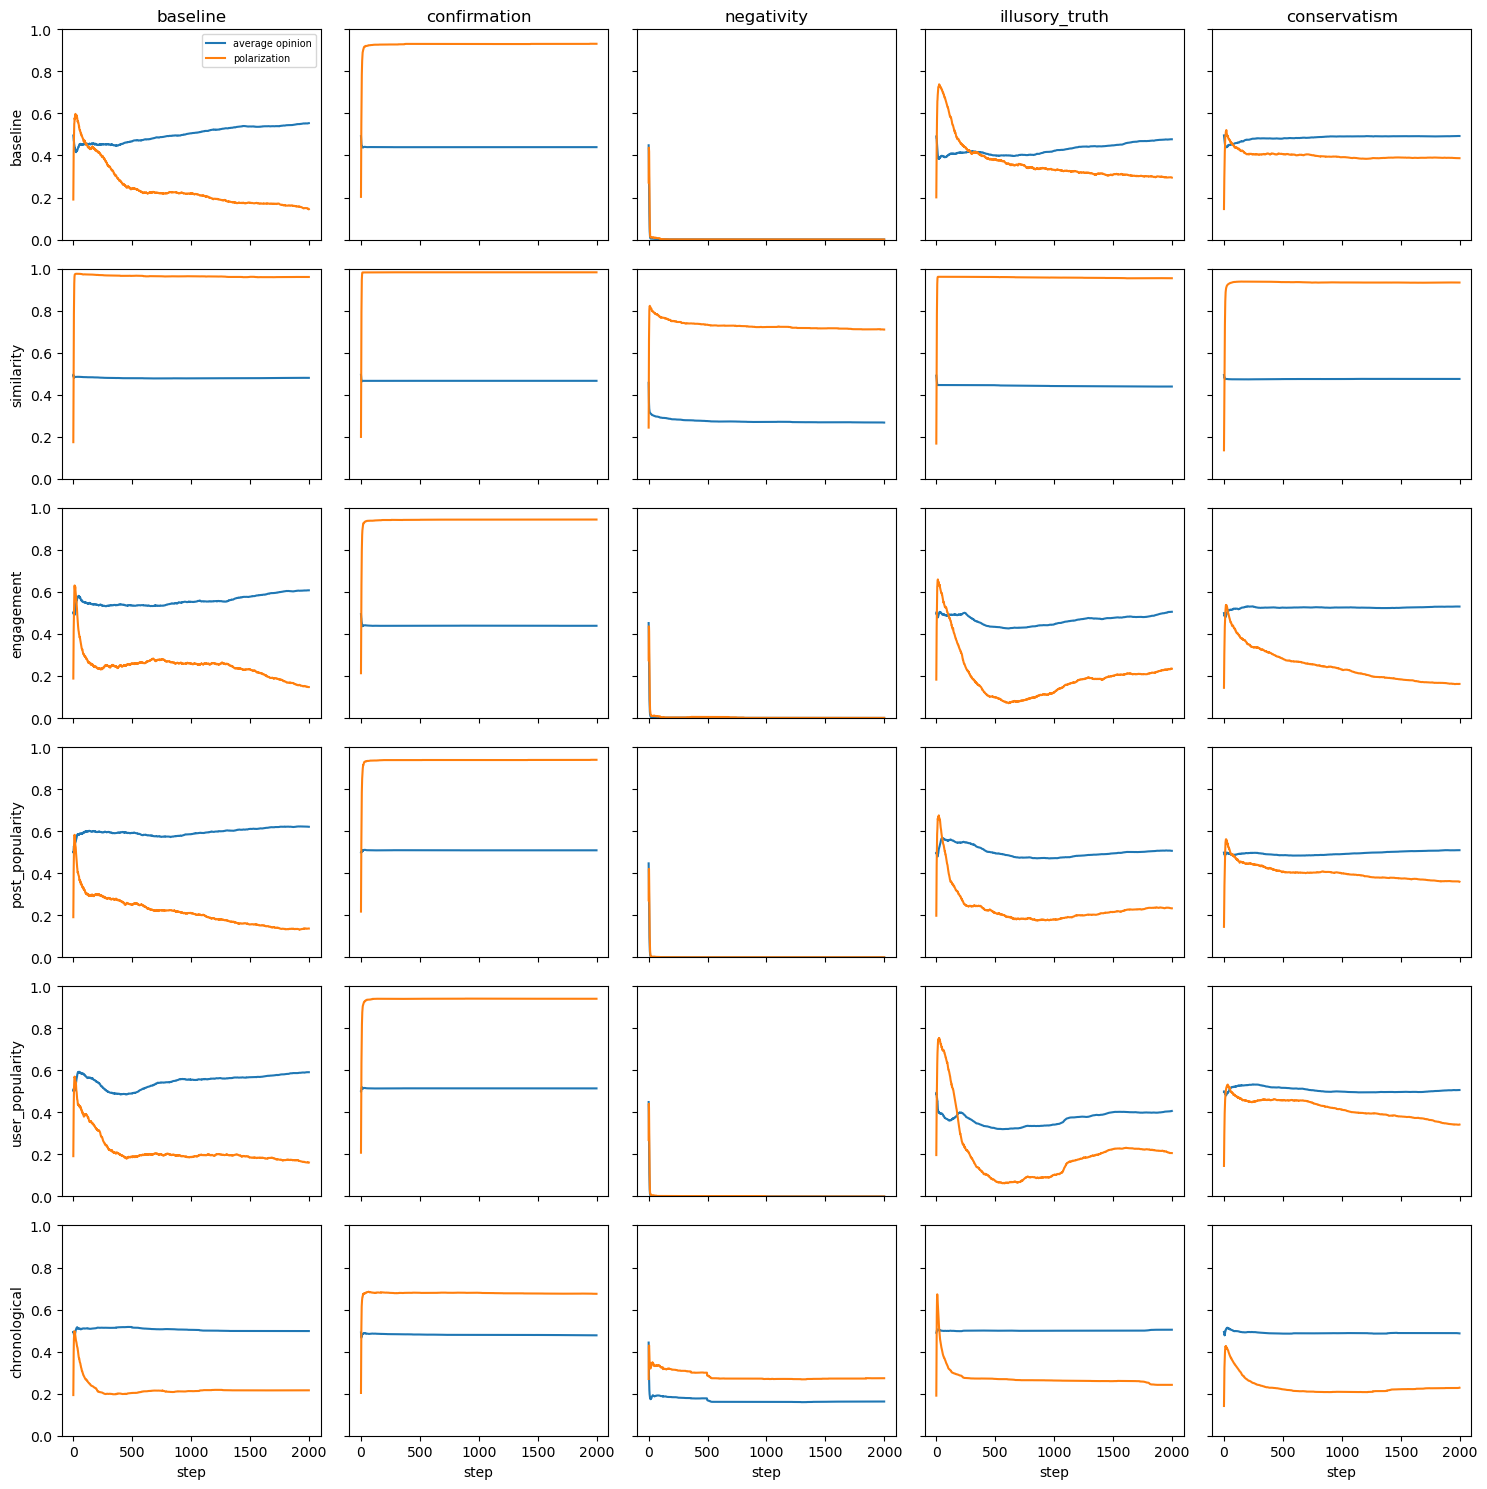

In [12]:
def plot_data(ax, steps, mean_over_reps, variance_over_reps):
    ax.plot(steps, mean_over_reps, label="average opinion")
    ax.plot(steps, 4 * variance_over_reps, label="polarization")
    ax.set_ylim(0, 1)

n_rows, n_cols = len(rankers), len(bias_settings)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 2.5 * n_rows),
                         sharex=True, sharey=True)

for i, ranker in enumerate(rankers):
    for j, bias_name in enumerate(bias_settings):
        ax = axes[i, j]
        steps, mean_over_reps, variance_over_reps = data[(ranker, bias_name)]
        plot_data(ax, steps, mean_over_reps, variance_over_reps)
        if i == 0:
            ax.set_title(bias_name)
        if j == 0:
            ax.set_ylabel(ranker)
        if i == n_rows - 1:
            ax.set_xlabel("step")

axes[0, 0].legend(fontsize=7)
plt.tight_layout()
plt.show()

fig.savefig("ranker_bias_comparison.pdf", dpi=300)

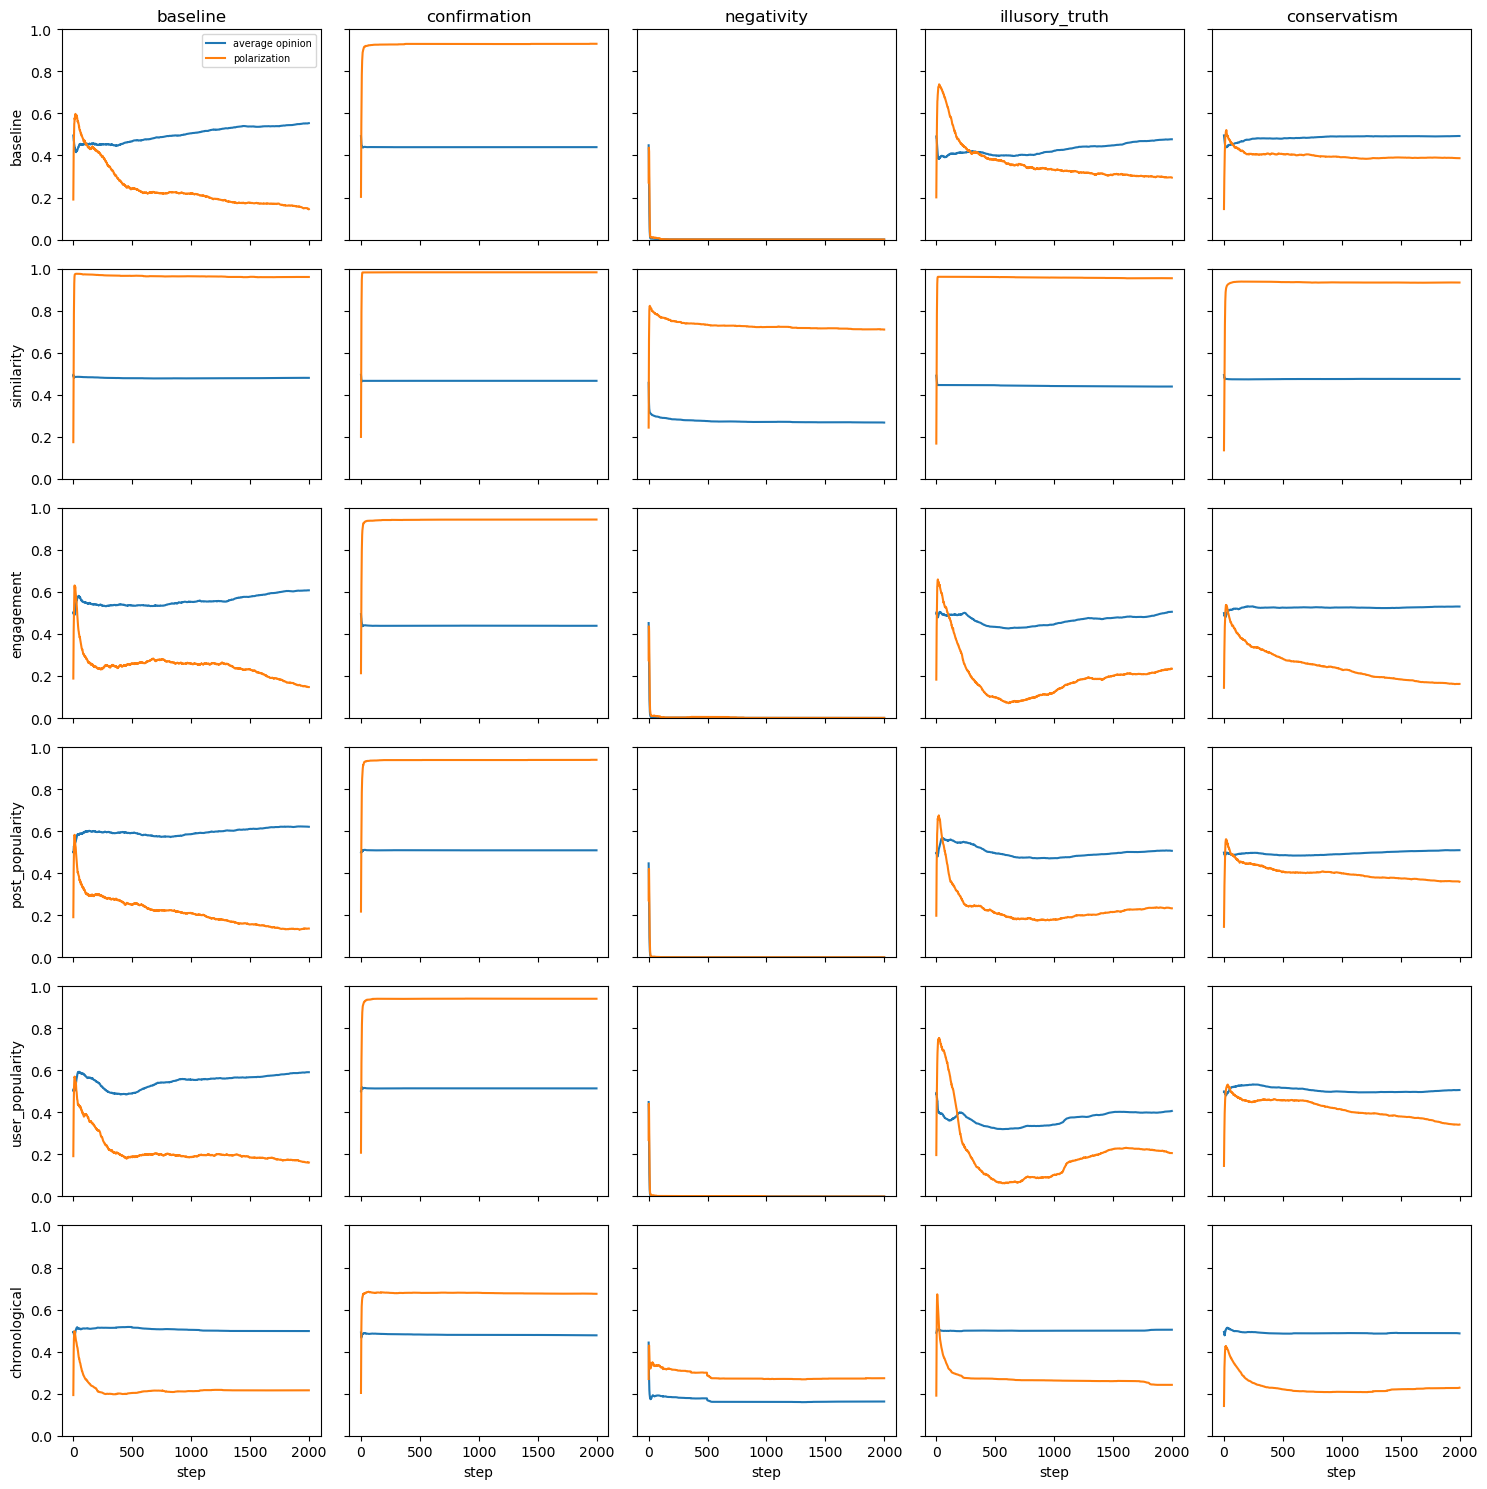

In [11]:
def plot_data(ax, steps, mean_over_reps, variance_over_reps):
    ax.plot(steps, mean_over_reps, label="average opinion")
    ax.plot(steps, 4 * variance_over_reps, label="polarization")
    ax.set_ylim(0, 1)

n_rows, n_cols = len(rankers), len(bias_settings)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 2.5 * n_rows),
                         sharex=True, sharey=True)

for i, ranker in enumerate(rankers):
    for j, bias_name in enumerate(bias_settings):
        ax = axes[i, j]
        steps, mean_over_reps, variance_over_reps = data[(ranker, bias_name)]
        plot_data(ax, steps, mean_over_reps, variance_over_reps)
        if i == 0:
            ax.set_title(bias_name)
        if j == 0:
            ax.set_ylabel(ranker)
        if i == n_rows - 1:
            ax.set_xlabel("step")

axes[0, 0].legend(fontsize=7)
plt.tight_layout()
plt.show()